# IT2214 — Data Preparation & Exploration

**Name:** Lee David Aiden  |  **Admin No:** 250756M  |  **Class:** AA2501

Dataset: `gym_members_exercise_tracking.csv` — gym member exercise records
Target variable: **`Calories_Burned`** (interval → regression problem)


---
## Cell 1 — Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Cell 2 — Load the raw data and audit it

📸 **Screenshot this output → Figure 1:** *Initial data audit showing 4,865 records across 15
variables with no missing values.*

In [2]:
df = pd.read_csv("gym_members_exercise_tracking.csv")

print("=" * 55)
print("SHAPE (rows, columns):", df.shape)
print("=" * 55)
print("\n--- DATA TYPES ---")
print(df.dtypes)
print("\n--- MISSING VALUES PER COLUMN ---")
print(df.isna().sum())
print("\n--- EXACT DUPLICATE ROWS ---")
print(df.duplicated().sum())

SHAPE (rows, columns): (4865, 15)

--- DATA TYPES ---
Age                                int64
Gender                               str
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                    int64
Workout_Type                         str
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object

--- MISSING VALUES PER COLUMN ---
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Ca

---
## Cell 3 — Descriptive statistics on the raw data

📸 **Screenshot → Figure 2:** *Descriptive statistics of the raw dataset.*

In [3]:
print("--- NUMERIC VARIABLES ---")
display(df.describe().T.round(2))

print("\n--- CATEGORICAL VARIABLES ---")
print("Gender       :", df["Gender"].unique())
print("Workout_Type :", df["Workout_Type"].unique())

--- NUMERIC VARIABLES ---


,count,mean,std,min,25%,50%,75%,max
Age,4865.0,38.68,12.18,18.00,28.00,40.00,49.00,59.00
Weight (kg),4865.0,73.85,21.20,40.00,58.10,70.00,86.00,129.90
Height (m),4865.0,1.72,0.13,1.50,1.62,1.71,1.80,2.00
Max_BPM,4865.0,179.88,11.52,160.00,170.00,180.00,190.00,199.00
Avg_BPM,4865.0,143.77,14.34,120.00,131.00,143.00,156.00,169.00
Resting_BPM,4865.0,62.22,7.32,50.00,56.00,62.00,68.00,74.00
Session_Duration (hours),4865.0,1.26,0.34,0.50,1.04,1.26,1.46,2.00
Calories_Burned,4865.0,905.42,272.53,303.00,720.00,893.00,1076.00,1783.00
Fat_Percentage,4865.0,24.98,6.26,10.00,21.30,26.20,29.30,35.00
Water_Intake (liters),4865.0,2.63,0.60,1.50,2.20,2.60,3.10,3.70



--- CATEGORICAL VARIABLES ---
Gender       : <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Workout_Type : <StringArray>
['Yoga', 'HIIT', 'Cardio', 'Strength']
Length: 4, dtype: str


---
## Cell 4 — Removing Duplicate records

📸 **Screenshot → Figure 3:** *De-duplication reduced the dataset from 4,865 to 973 unique records.*

In [4]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)

print("=" * 55)
print(f"Rows before de-duplication : {before:>6,}")
print(f"Duplicate rows removed     : {before - after:>6,}  ({(before-after)/before:.1%})")
print(f"Unique records retained    : {after:>6,}")
print("=" * 55)

Rows before de-duplication :  4,865
Duplicate rows removed     :  3,892  (80.0%)
Unique records retained    :    973


---
## Cell 5 — Physiologically impossible heart rates

Rule: the **average** heart rate during a session cannot exceed the **maximum** heart rate recorded
in that same session (`Avg_BPM` ≤ `Max_BPM` by definition).

📸 **Screenshot → Figure 4:** *Records where Avg_BPM exceeded Max_BPM, identified and removed.*

In [5]:
invalid_hr = df[df["Avg_BPM"] > df["Max_BPM"]]

print(f"Records where Avg_BPM > Max_BPM: {len(invalid_hr)}\n")
display(invalid_hr[["Age", "Gender", "Max_BPM", "Avg_BPM",
                    "Resting_BPM", "Calories_Burned"]].head(10))

# Treatment: delete. The true values are unrecoverable and the affected
# rows are a small fraction of the data.
df = df[df["Avg_BPM"] <= df["Max_BPM"]].reset_index(drop=True)
print(f"\nRows remaining after removal: {len(df)}")

Records where Avg_BPM > Max_BPM: 23



,Age,Gender,Max_BPM,Avg_BPM,Resting_BPM,Calories_Burned
16,19,Female,166,167,58,1111
46,24,Male,160,167,53,772
56,59,Female,161,162,61,1021
95,59,Female,164,169,64,441
106,41,Male,162,168,51,424
230,28,Male,161,162,70,1034
310,52,Female,164,165,68,1359
326,48,Male,160,167,58,1223
356,31,Female,168,169,74,1318
365,39,Female,162,167,63,768



Rows remaining after removal: 950


---
## Cell 6 — Validity and consistency checks

📸 **Screenshot → Figure 5:** *Consistency and range validation — no further anomalies detected.*

In [6]:
bmi_recalc = (df["Weight (kg)"] / df["Height (m)"] ** 2).round(2)

print("--- CONSISTENCY CHECKS ---")
print("BMI differing from recalculated Weight/Height^2 by >0.5 :",
      (abs(bmi_recalc - df["BMI"]) > 0.5).sum())
print("Records where Resting_BPM > Avg_BPM (implausible)       :",
      (df["Resting_BPM"] > df["Avg_BPM"]).sum())

print("\n--- RANGE CHECKS ---")
display(df[["Age", "Height (m)", "Weight (kg)", "Resting_BPM",
            "Fat_Percentage", "Session_Duration (hours)"]]
        .agg(["min", "max"]).round(2))

print("--- CATEGORY CHECKS ---")
print("Gender       :", sorted(df["Gender"].unique()))
print("Workout_Type :", sorted(df["Workout_Type"].unique()))

--- CONSISTENCY CHECKS ---
BMI differing from recalculated Weight/Height^2 by >0.5 : 0
Records where Resting_BPM > Avg_BPM (implausible)       : 0

--- RANGE CHECKS ---


,Age,Height (m),Weight (kg),Resting_BPM,Fat_Percentage,Session_Duration (hours)
min,18,1.5,40.0,50,10.0,0.5
max,59,2.0,129.9,74,35.0,2.0


--- CATEGORY CHECKS ---
Gender       : ['Female', 'Male']
Workout_Type : ['Cardio', 'HIIT', 'Strength', 'Yoga']


---
## Cell 7 — Rename columns for SAS Viya compatibility

📸 **Screenshot → Figure 6:** *Column renaming for SAS Viya compatibility.*

In [7]:
df = df.rename(columns={
    "Weight (kg)": "Weight_kg",
    "Height (m)": "Height_m",
    "Session_Duration (hours)": "Session_Duration_hrs",
    "Water_Intake (liters)": "Water_Intake_L",
    "Workout_Frequency (days/week)": "Workout_Frequency",
})

for c in df.columns:
    print(" -", c)

 - Age
 - Gender
 - Weight_kg
 - Height_m
 - Max_BPM
 - Avg_BPM
 - Resting_BPM
 - Session_Duration_hrs
 - Calories_Burned
 - Workout_Type
 - Fat_Percentage
 - Water_Intake_L
 - Workout_Frequency
 - Experience_Level
 - BMI


---
## Cell 8 — Feature engineering

Three derived features are created and their correlation with the target is measured.

📸 **Screenshot → Figure 7:** *Engineered features and their correlation with the target.*

In [8]:
df["BPM_Reserve"]     = df["Max_BPM"] - df["Resting_BPM"]
df["Intensity_Ratio"] = (df["Avg_BPM"] / df["Max_BPM"]).round(3)

display(df[["Max_BPM", "Resting_BPM", "BPM_Reserve",
            "Avg_BPM", "Intensity_Ratio"]].head())

print("\nCorrelation with Calories_Burned:")
print(" BPM_Reserve     :", round(df["BPM_Reserve"].corr(df["Calories_Burned"]), 3))
print(" Intensity_Ratio :", round(df["Intensity_Ratio"].corr(df["Calories_Burned"]), 3))
print(" Avg_BPM (raw)   :", round(df["Avg_BPM"].corr(df["Calories_Burned"]), 3))

,Max_BPM,Resting_BPM,BPM_Reserve,Avg_BPM,Intensity_Ratio
0,180,60,120,157,0.872
1,179,66,113,151,0.844
2,167,54,113,122,0.731
3,190,56,134,164,0.863
4,188,68,120,158,0.840



Correlation with Calories_Burned:
 BPM_Reserve     : -0.002
 Intensity_Ratio : 0.296
 Avg_BPM (raw)   : 0.35


In [9]:
df = df.drop(columns=["BPM_Reserve", "Intensity_Ratio"])
print("Engineered features dropped. Remaining columns:", len(df.columns))

Engineered features dropped. Remaining columns: 15


---
# Data Exploration

---
## Cell 9 — Target variable distribution

📸 **Screenshot → Figure 7 (report):** *Distribution of the target variable.*

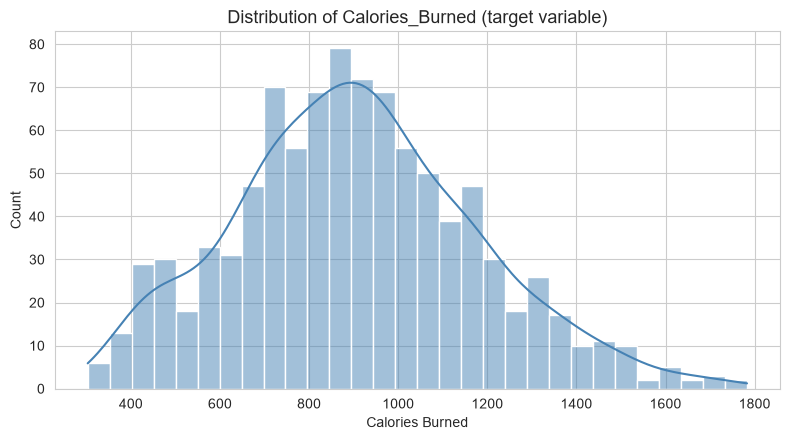

Mean     : 904.7
Median   : 888.0
Std dev  : 272.9
Skewness : 0.293


In [10]:
plt.figure(figsize=(8, 4.5))
sns.histplot(df["Calories_Burned"], kde=True, bins=30, color="steelblue")
plt.title("Distribution of Calories_Burned (target variable)", fontsize=13)
plt.xlabel("Calories Burned")
plt.tight_layout()
plt.savefig("fig_target_distribution.png", dpi=150)
plt.show()

print("Mean     :", round(df["Calories_Burned"].mean(), 1))
print("Median   :", df["Calories_Burned"].median())
print("Std dev  :", round(df["Calories_Burned"].std(), 1))
print("Skewness :", round(df["Calories_Burned"].skew(), 3))

---
## Cell 10 — Correlation with the target

📸 **Screenshot → Figure 8:** *Correlation matrix. Session duration (r = 0.91) and body fat
percentage (r = −0.60) show the strongest relationships with the target.*

--- CORRELATION WITH Calories_Burned ---
Calories_Burned         1.000
Session_Duration_hrs    0.909
Experience_Level        0.696
Workout_Frequency       0.581
Water_Intake_L          0.366
Avg_BPM                 0.350
Height_m                0.097
Weight_kg               0.097
BMI                     0.055
Resting_BPM             0.010
Max_BPM                 0.005
Age                    -0.154
Fat_Percentage         -0.601
Name: Calories_Burned, dtype: float64


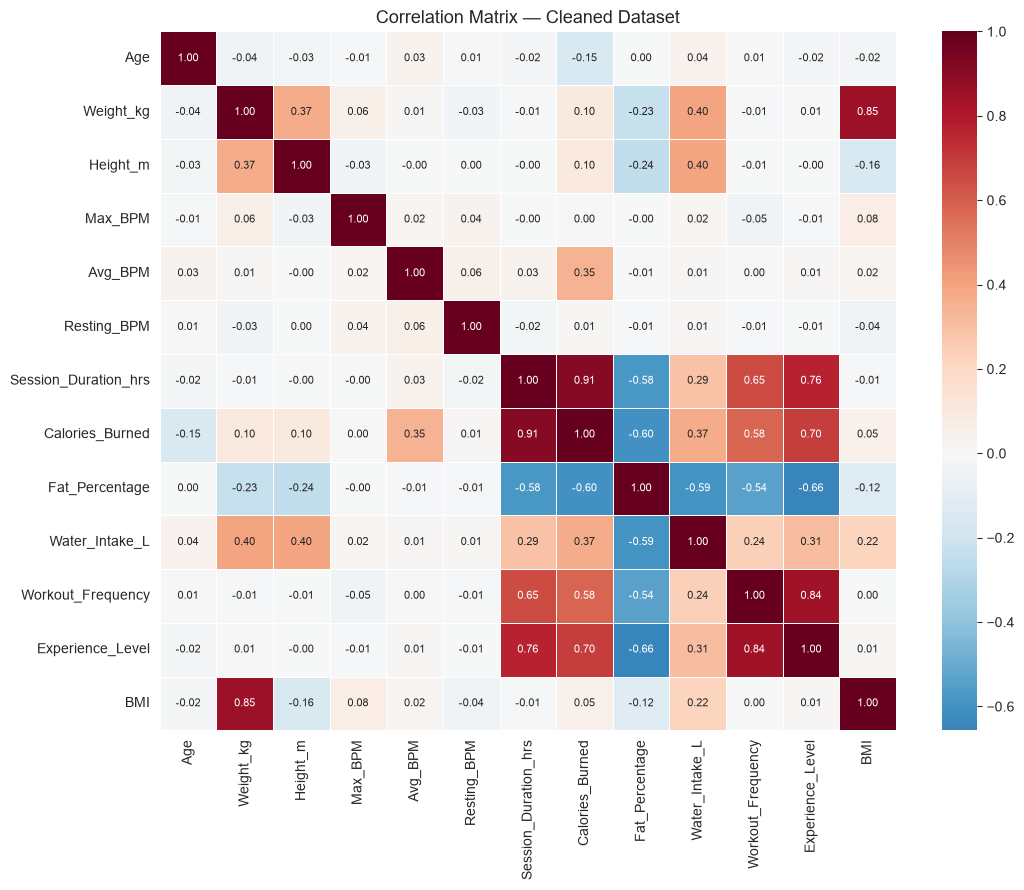

In [11]:
num = df.select_dtypes(include=np.number)

print("--- CORRELATION WITH Calories_Burned ---")
print(num.corr()["Calories_Burned"].sort_values(ascending=False).round(3))

plt.figure(figsize=(11, 9))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, annot_kws={"size": 8}, linewidths=0.5)
plt.title("Correlation Matrix — Cleaned Dataset", fontsize=13)
plt.tight_layout()
plt.savefig("fig_correlation.png", dpi=150)
plt.show()

---
## Cell 11 — Key relationship plots

📸 **Screenshot → Figures 9–11:** *Exploratory relationship plots.*

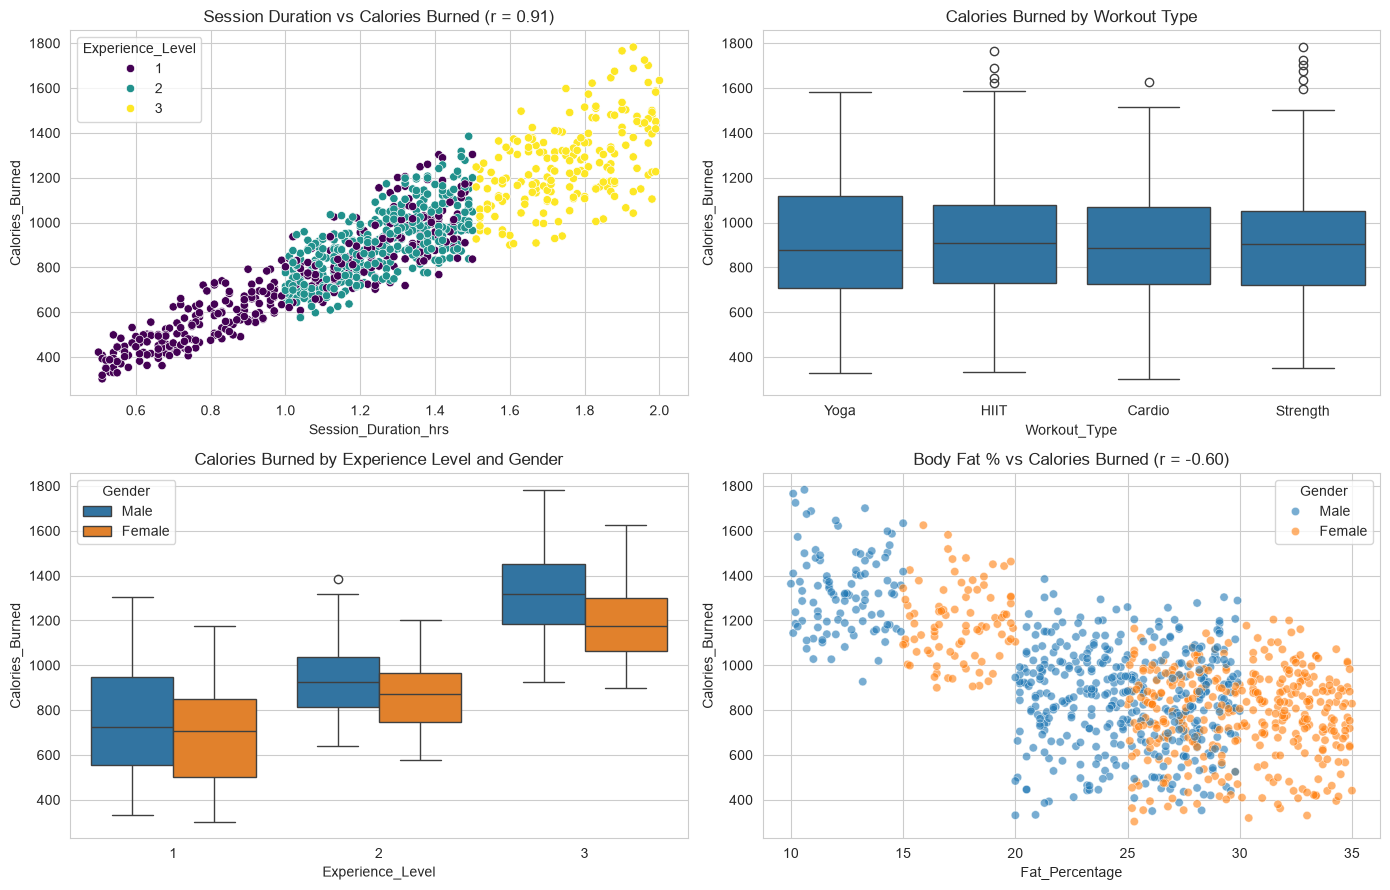

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

sns.scatterplot(data=df, x="Session_Duration_hrs", y="Calories_Burned",
                hue="Experience_Level", palette="viridis", ax=ax[0, 0])
ax[0, 0].set_title("Session Duration vs Calories Burned (r = 0.91)")

sns.boxplot(data=df, x="Workout_Type", y="Calories_Burned", ax=ax[0, 1])
ax[0, 1].set_title("Calories Burned by Workout Type")

sns.boxplot(data=df, x="Experience_Level", y="Calories_Burned",
            hue="Gender", ax=ax[1, 0])
ax[1, 0].set_title("Calories Burned by Experience Level and Gender")

sns.scatterplot(data=df, x="Fat_Percentage", y="Calories_Burned",
                hue="Gender", alpha=0.6, ax=ax[1, 1])
ax[1, 1].set_title("Body Fat % vs Calories Burned (r = -0.60)")

plt.tight_layout()
plt.savefig("fig_eda_panels.png", dpi=150)
plt.show()

---
## Cell 12 — Export the cleaned dataset for SAS Viya

📸 **Screenshot → Figure (optional):** *Cleaned dataset exported for SAS Viya import.*

In [13]:
df.to_csv("gym_clean.csv", index=False)

print("=" * 55)
print("CLEANING SUMMARY")
print("=" * 55)
print(f"Raw records                        : 4,865")
print(f"After removing duplicates          :   973")
print(f"After removing invalid heart rates : {len(df):>5,}")
print("=" * 55)
print("\nExported to: gym_clean.csv")
print("Final shape:", df.shape)
display(df.head())

CLEANING SUMMARY
Raw records                        : 4,865
After removing duplicates          :   973
After removing invalid heart rates :   950

Exported to: gym_clean.csv
Final shape: (950, 15)


,Age,Gender,Weight_kg,Height_m,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration_hrs,Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake_L,Workout_Frequency,Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556,Strength,29.2,2.8,3,1,14.39
